In [1]:
# Task 0 - Import libraries and load the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline
sns.set_theme(style="whitegrid")

DATA_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

# Try the official course URL first.
try:
    df = pd.read_csv(DATA_URL)
except Exception:
    # If the online URL is unavailable, upload historical_automobile_sales.csv
    # to Colab and run this cell again.
    df = pd.read_csv("/content/historical_automobile_sales.csv")

# Make the unemployment column name consistent with versions of the course dataset.
if "Unemployment_Rate" not in df.columns and "unemployment_rate" in df.columns:
    df.rename(columns={"unemployment_rate": "Unemployment_Rate"}, inplace=True)

# Make sure Date is a datetime column.
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Ensure Year and Month exist.
if "Year" not in df.columns and "Date" in df.columns:
    df["Year"] = df["Date"].dt.year
if "Month" not in df.columns and "Date" in df.columns:
    df["Month"] = df["Date"].dt.month

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (528, 15)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,Unemployment_Rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,1980-02-29,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,1980-03-31,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,1980-04-30,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,1980-05-31,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


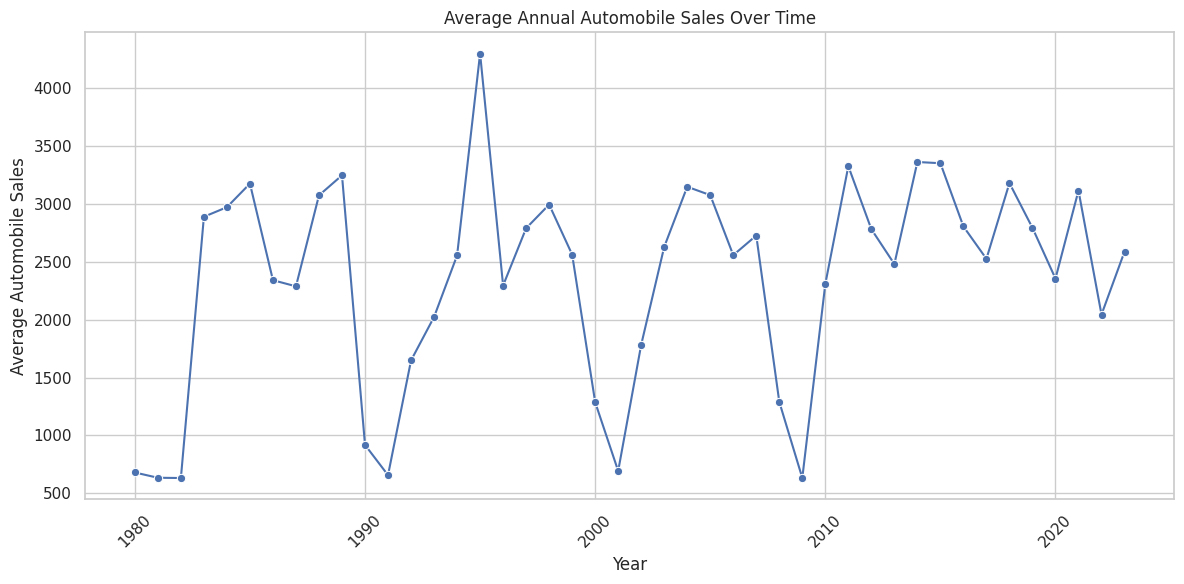

In [2]:
# TASK 1.1
df_line = df.groupby("Year")["Automobile_Sales"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_line, x="Year", y="Automobile_Sales", marker="o")
plt.title("Average Annual Automobile Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


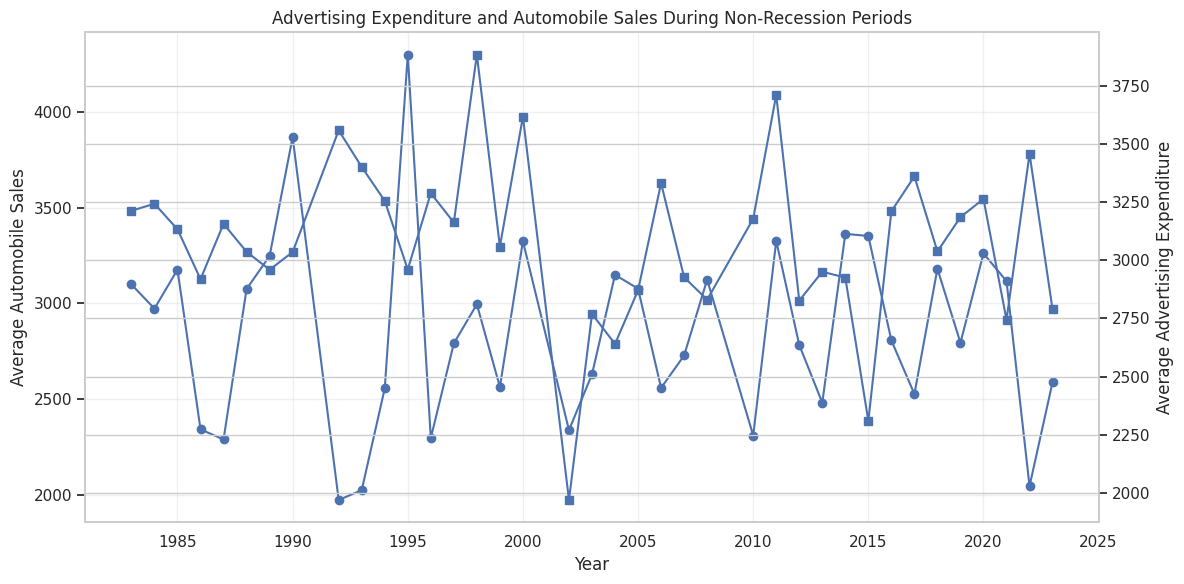

In [3]:
# TASK 1.2
non_recession_data = df[df["Recession"] == 0].copy()

non_recession_yearly = (
    non_recession_data.groupby("Year")[["Advertising_Expenditure", "Automobile_Sales"]]
    .mean()
    .reset_index()
)

# Use a secondary y-axis because advertising expenditure and sales can have different scales.
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    non_recession_yearly["Year"],
    non_recession_yearly["Automobile_Sales"],
    marker="o",
    label="Average Automobile Sales"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Automobile Sales")

ax2 = ax1.twinx()
ax2.plot(
    non_recession_yearly["Year"],
    non_recession_yearly["Advertising_Expenditure"],
    marker="s",
    label="Average Advertising Expenditure"
)
ax2.set_ylabel("Average Advertising Expenditure")

ax1.set_title("Advertising Expenditure and Automobile Sales During Non-Recession Periods")
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


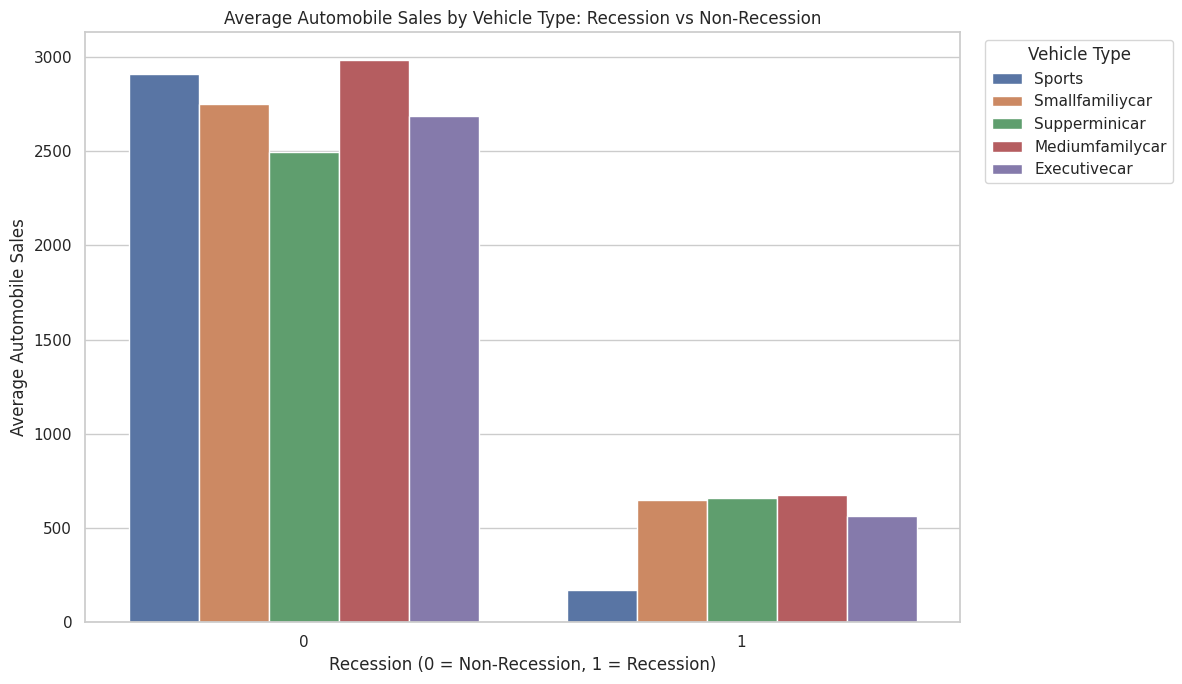

In [4]:
# TASK 1.3
plt.figure(figsize=(12, 7))

sns.barplot(
    data=df,
    x="Recession",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    estimator="mean",
    errorbar=None
)

plt.title("Average Automobile Sales by Vehicle Type: Recession vs Non-Recession")
plt.xlabel("Recession (0 = Non-Recession, 1 = Recession)")
plt.ylabel("Average Automobile Sales")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


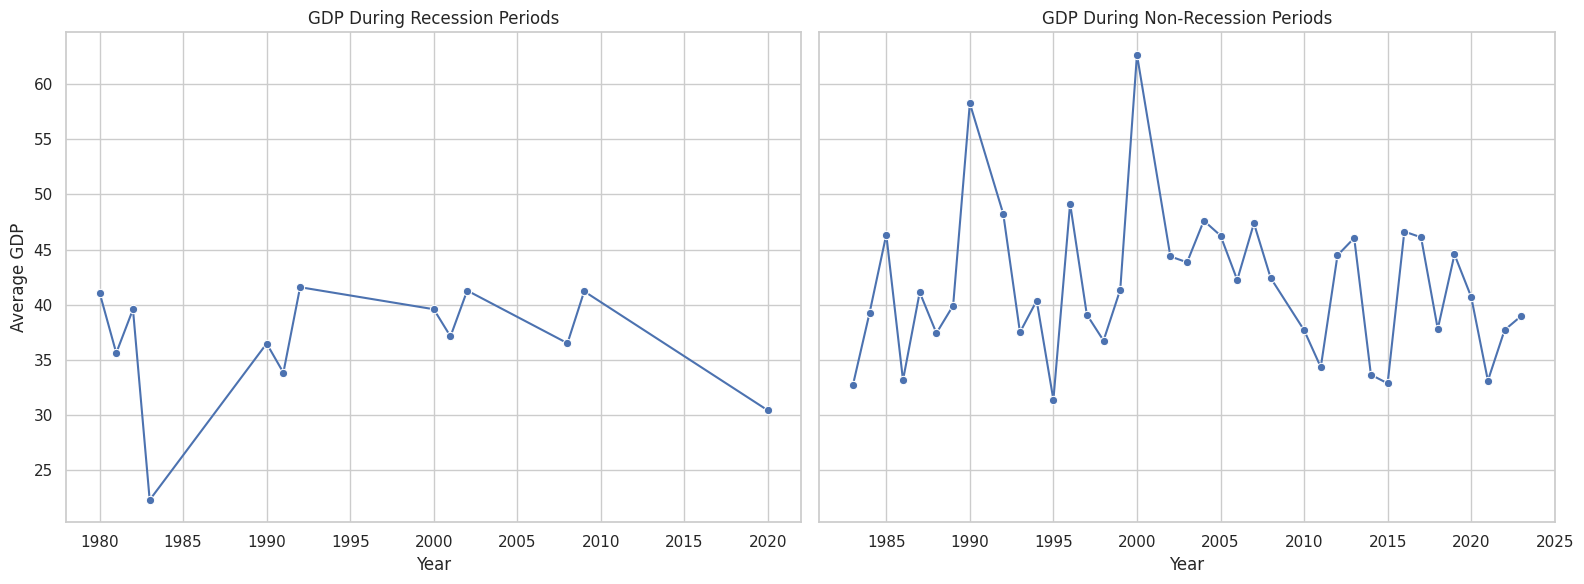

In [5]:
# TASK 1.4
recession_data = df[df["Recession"] == 1]
non_recession_data = df[df["Recession"] == 0]

gdp_recession = recession_data.groupby("Year")["GDP"].mean().reset_index()
gdp_non_recession = non_recession_data.groupby("Year")["GDP"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.lineplot(
    data=gdp_recession,
    x="Year",
    y="GDP",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("GDP During Recession Periods")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")

sns.lineplot(
    data=gdp_non_recession,
    x="Year",
    y="GDP",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("GDP During Non-Recession Periods")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average GDP")

plt.tight_layout()
plt.show()


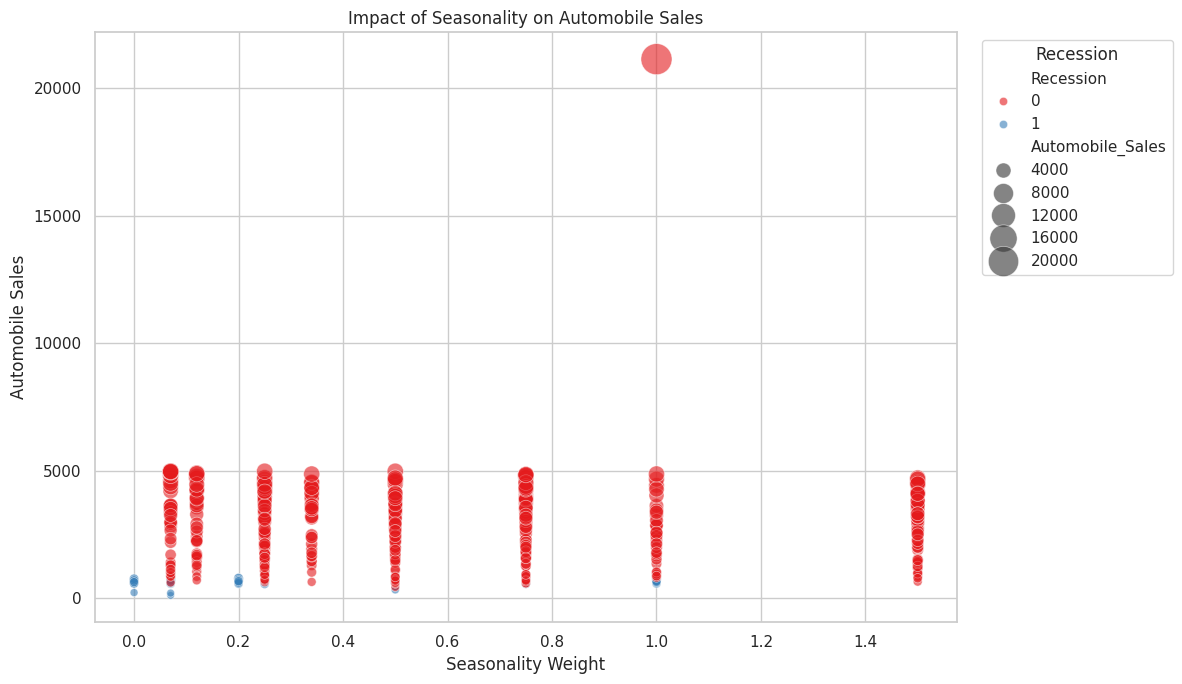

In [6]:
# TASK 1.5
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Seasonality_Weight",
    y="Automobile_Sales",
    size="Automobile_Sales",
    hue="Recession",
    sizes=(30, 500),
    alpha=0.6,
    palette="Set1"
)

plt.title("Impact of Seasonality on Automobile Sales")
plt.xlabel("Seasonality Weight")
plt.ylabel("Automobile Sales")
plt.legend(title="Recession", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


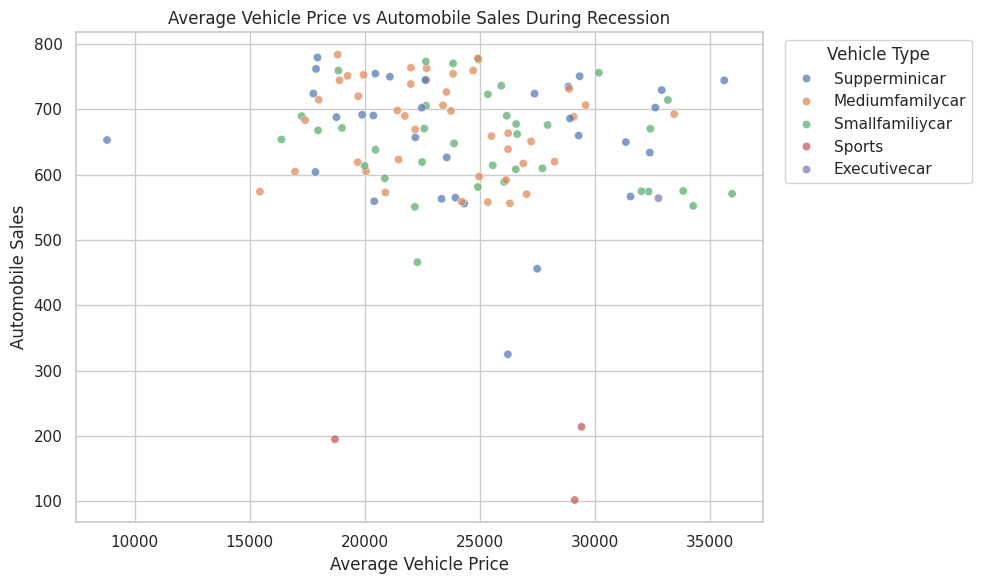

In [7]:
# TASK 1.6
recession_data = df[df["Recession"] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=recession_data,
    x="Price",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    alpha=0.7
)

plt.title("Average Vehicle Price vs Automobile Sales During Recession")
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


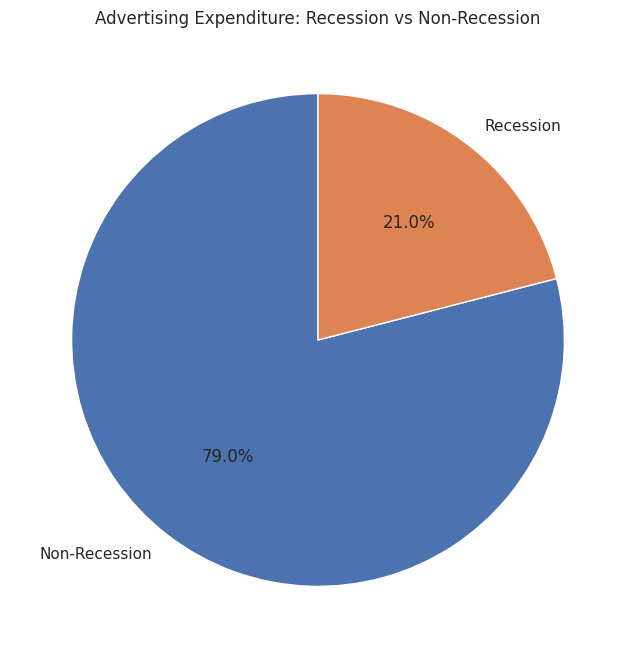

In [8]:
# TASK 1.7
advertising_by_recession = (
    df.groupby("Recession")["Advertising_Expenditure"]
    .sum()
    .rename(index={0: "Non-Recession", 1: "Recession"})
)

plt.figure(figsize=(8, 8))
plt.pie(
    advertising_by_recession.values,
    labels=advertising_by_recession.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Advertising Expenditure: Recession vs Non-Recession")
plt.ylabel("")
plt.show()


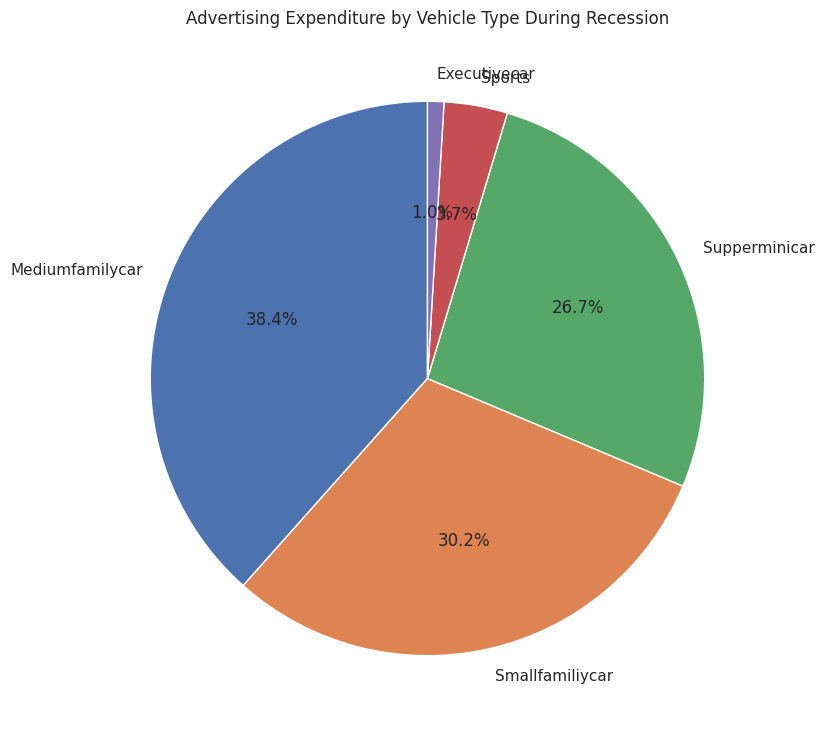

In [9]:
# TASK 1.8
recession_advertising_by_vehicle = (
    recession_data.groupby("Vehicle_Type")["Advertising_Expenditure"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 9))
plt.pie(
    recession_advertising_by_vehicle.values,
    labels=recession_advertising_by_vehicle.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Advertising Expenditure by Vehicle Type During Recession")
plt.ylabel("")
plt.show()


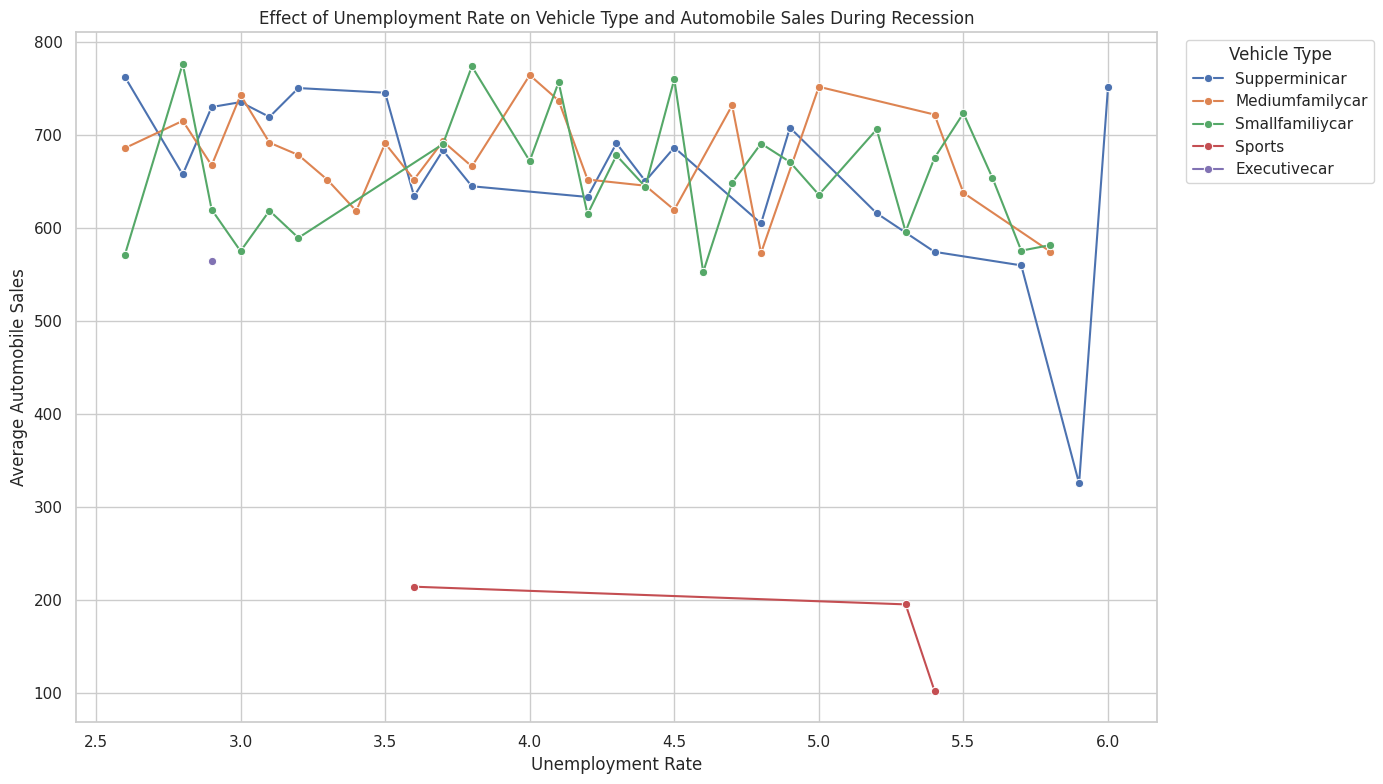

In [10]:
# TASK 1.9
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=recession_data,
    x="Unemployment_Rate",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    marker="o",
    estimator="mean",
    errorbar=None
)

plt.title("Effect of Unemployment Rate on Vehicle Type and Automobile Sales During Recession")
plt.xlabel("Unemployment Rate")
plt.ylabel("Average Automobile Sales")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
